Epoch 1: Loss = 0.5939, Val Accuracy = 0.7250
Epoch 2: Loss = 0.3535, Val Accuracy = 0.9250
Epoch 3: Loss = 0.1899, Val Accuracy = 0.9250
Epoch 4: Loss = 0.1725, Val Accuracy = 0.9450
Epoch 5: Loss = 0.0954, Val Accuracy = 0.9750
Epoch 6: Loss = 0.0637, Val Accuracy = 0.9600
Epoch 7: Loss = 0.0553, Val Accuracy = 0.9650
Epoch 8: Loss = 0.0497, Val Accuracy = 0.9650
Epoch 9: Loss = 0.0892, Val Accuracy = 0.9250
Epoch 10: Loss = 0.0883, Val Accuracy = 0.9400


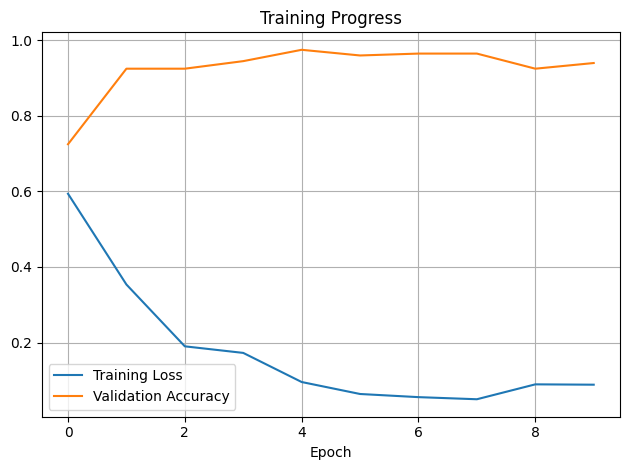

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

# --- Set random seeds for reproducibility ---
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# --- Synthetic dataset generation ---
def generate_sequence(length=10):
    seq = np.random.randint(0, 10, size=length)
    label = int(seq.sum() > (length * 5))
    return seq, label

class SequenceDataset(Dataset):
    def __init__(self, num_samples=1000, seq_len=10):
        self.data = [generate_sequence(seq_len) for _ in range(num_samples)]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq, label = self.data[idx]
        return torch.tensor(seq, dtype=torch.long), torch.tensor(label, dtype=torch.long)

train_dataset = SequenceDataset(800)
val_dataset = SequenceDataset(200)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# --- Sinusoidal positional encoding ---
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

# --- Transformer classifier with nn.MultiheadAttention ---
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size=10, d_model=64, nhead=4, num_classes=2, num_layers=1, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = SinusoidalPositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.embedding(x)  # (batch, seq_len, d_model)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)  # global average pooling
        return self.classifier(x)

# --- Training loop ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses, val_accuracies = [], []

for epoch in range(10):
    model.train()
    total_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_losses.append(total_loss / len(train_loader))

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    val_accuracy = correct / total
    val_accuracies.append(val_accuracy)
    print(f"Epoch {epoch+1}: Loss = {train_losses[-1]:.4f}, Val Accuracy = {val_accuracy:.4f}")

# --- Plot results ---
plt.plot(train_losses, label="Training Loss")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.title("Training Progress")
plt.grid(True)
plt.tight_layout()
plt.show()